# 02 · Comparación de modelos

Tabla comparativa final (baseline, GRU, Transformer, híbrido) sobre el **mismo test set**, segmentación K-means y análisis de errores del ensamble (M4, §5).

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'SPEC.md').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, torch
from src import config
from src.data import features, sequence
from src.models.gru import GRUClassifier
from src.models.transformer import TransformerClassifier
from src.models.ensemble import HybridEnsemble
from src.models import clustering

metrics = json.loads((ROOT/'results'/'metrics.json').read_text())
meta = json.loads((ROOT/'artifacts'/'metadata.json').read_text())
vocab = json.loads((ROOT/'artifacts'/'vocab.json').read_text())
print('dataset:', metrics['dataset'], '| n_test:', metrics['n_test'])

dataset: retailrocket | n_test: 25032


## 1. Tabla comparativa de métricas

In [2]:
table = pd.DataFrame(metrics['models']).T[['accuracy','precision','recall','f1','auc']]
table = table.sort_values('auc', ascending=False).round(4)
print(table.to_string())
print('\nbaseline elegido:', meta['baseline']['best'])
print('ensemble:', meta['ensemble'])

             accuracy  precision  recall      f1     auc
ensemble       0.9425     0.3966  0.6802  0.5010  0.9453
gru            0.8851     0.2628  0.9445  0.4112  0.9445
transformer    0.8831     0.2596  0.9454  0.4073  0.9430
baseline       0.8705     0.2357  0.9135  0.3747  0.9164

baseline elegido: logreg
ensemble: {'method': 'stacking', 'threshold': 0.8914603279360482}


## 2. Comparación visual (F1 y AUC)

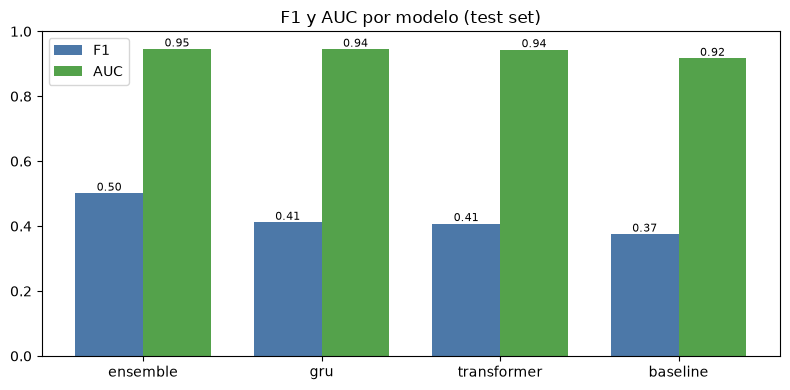

In [3]:
order = table.index.tolist()
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w/2, table['f1'], w, label='F1', color='#4C78A8')
ax.bar(x+w/2, table['auc'], w, label='AUC', color='#54A24B')
ax.set_xticks(x, order); ax.set_ylim(0,1); ax.legend()
ax.set_title('F1 y AUC por modelo (test set)')
for i,(f,a) in enumerate(zip(table['f1'],table['auc'])):
    ax.text(i-w/2,f,f'{f:.2f}',ha='center',va='bottom',fontsize=8)
    ax.text(i+w/2,a,f'{a:.2f}',ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()

## 3. Importancia de variables (baseline)

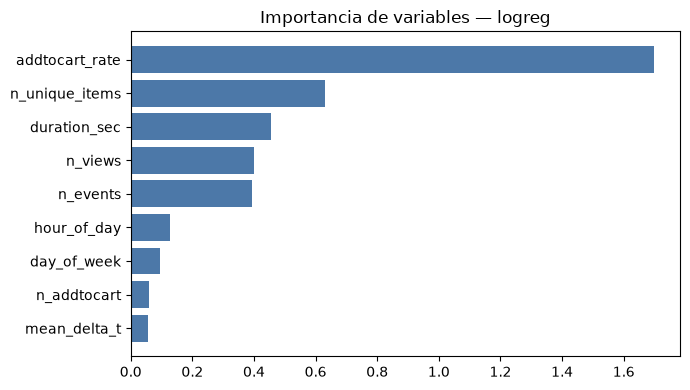

In [4]:
imp = pd.Series(meta['importances']).sort_values()
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(imp.index, imp.values, color='#4C78A8')
ax.set_title(f"Importancia de variables — {meta['baseline']['best']}")
plt.tight_layout(); plt.show()

## 4. Segmentación K-means

Distribución de segmentos en el test set y su tasa de conversión.

                        n    conv
segment                          
carrito abandonado  17003  0.0052
comparador            739  0.1123
decidido             2886  0.2509
explorador           4404  0.0379


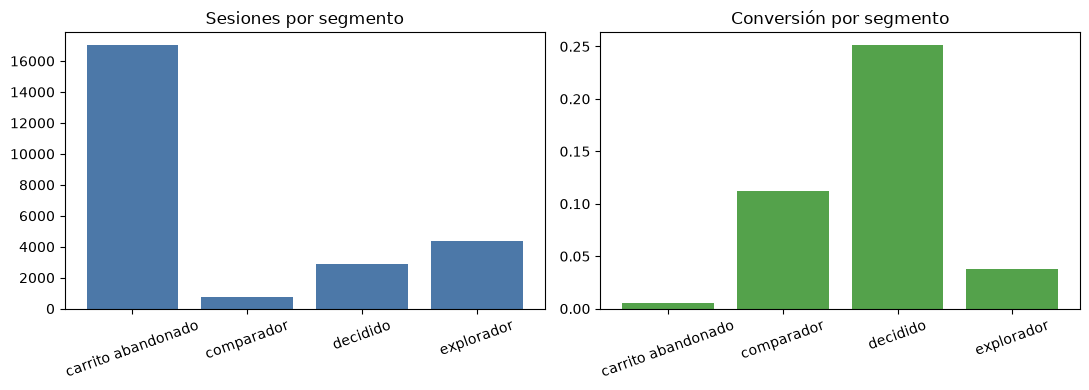

In [5]:
sessions = pd.read_parquet(ROOT/'data'/'processed'/'sessions.parquet')
test = sessions[sessions['split']=='test'].reset_index(drop=True)
scaler = joblib.load(ROOT/'artifacts'/'scaler.joblib')
kmeans = joblib.load(ROOT/'artifacts'/'kmeans.joblib')
names = clustering.name_clusters(kmeans.cluster_centers_, meta['feature_names'])
x_tab = features.tabular_from_sessions(test)
clusters = kmeans.predict(scaler.transform(x_tab.to_numpy(dtype=float)))
test = test.assign(segment=[names[c] for c in clusters])
seg = test.groupby('segment').agg(n=('converted','size'), conv=('converted','mean')).round(4)
print(seg.to_string())

fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4))
a1.bar(seg.index, seg['n'], color='#4C78A8'); a1.set_title('Sesiones por segmento')
a1.tick_params(axis='x', rotation=20)
a2.bar(seg.index, seg['conv'], color='#54A24B'); a2.set_title('Conversión por segmento')
a2.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 5. Análisis de errores del ensamble

Distribución de `p_final` por clase real y errores en el umbral calibrado.

umbral=0.891 | falsos positivos=1100 | falsos negativos=340


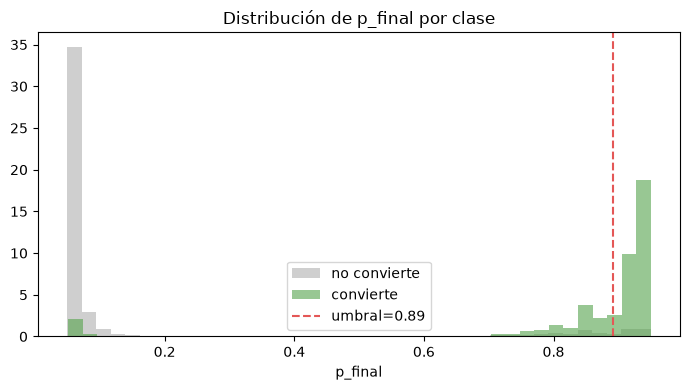

In [6]:
y = test['converted'].to_numpy()
loader = sequence.make_loader(sequence.SessionDataset(test, vocab['delta_mean'], vocab['delta_std']), config.BATCH_SIZE, False)
base = joblib.load(ROOT/'artifacts'/'baseline.joblib')
probs = {'baseline': base.predict_proba(scaler.transform(x_tab.to_numpy(dtype=float)))[:,1]}
for nm, M in (('gru',GRUClassifier()),('transformer',TransformerClassifier())):
    M.load_state_dict(torch.load(ROOT/'artifacts'/f'{nm}.pt', map_location='cpu'))
    probs[nm] = sequence.predict_proba(M, loader, 'cpu')
ens = HybridEnsemble.from_dict(json.loads((ROOT/'artifacts'/'ensemble.json').read_text()))
p = ens.combine(probs)
thr = ens.threshold
pred = (p>=thr).astype(int)
fp = int(((pred==1)&(y==0)).sum()); fn = int(((pred==0)&(y==1)).sum())
print(f'umbral={thr:.3f} | falsos positivos={fp} | falsos negativos={fn}')

fig,ax=plt.subplots(figsize=(7,4))
ax.hist(p[y==0], bins=40, alpha=0.6, label='no convierte', color='#B0B0B0', density=True)
ax.hist(p[y==1], bins=40, alpha=0.6, label='convierte', color='#54A24B', density=True)
ax.axvline(thr, color='#E45756', ls='--', label=f'umbral={thr:.2f}')
ax.set_xlabel('p_final'); ax.set_title('Distribución de p_final por clase'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Atención del Transformer (interpretación)

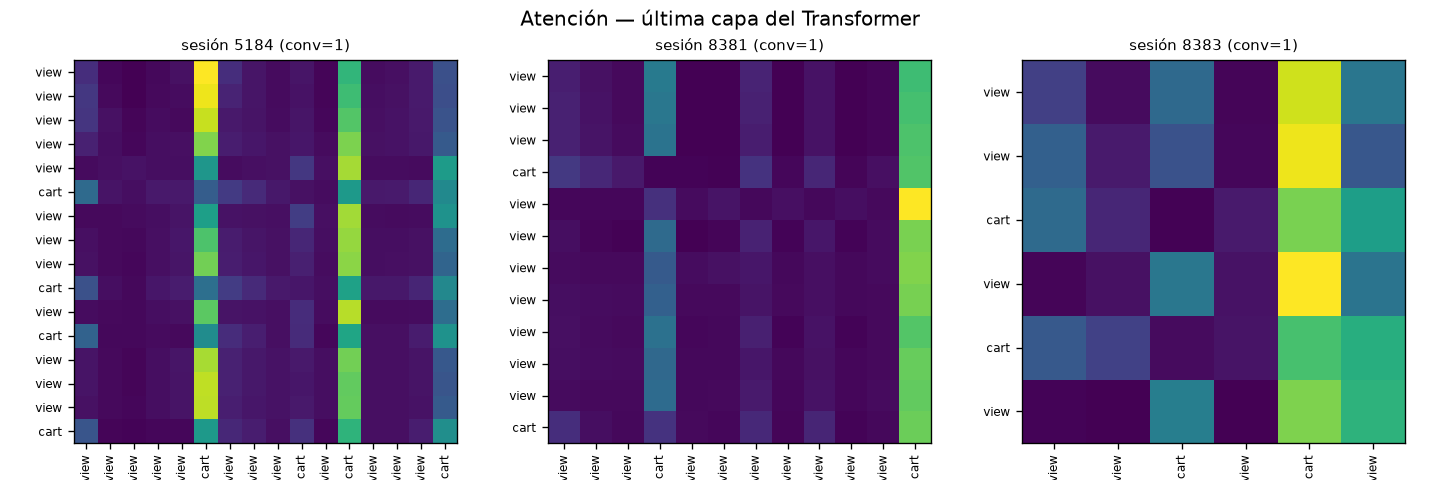

In [7]:
from IPython.display import Image
Image(filename=str(ROOT/'results'/'attention_heatmap.png'))

## Conclusiones

- Los modelos secuenciales (GRU/Transformer) superan al baseline en AUC: la secuencia de eventos aporta señal sobre las features tabulares agregadas.
- El ensamble híbrido combina las tres probabilidades y calibra el umbral en validación, mejorando el F1 operativo.
- Los segmentos K-means separan intención de compra (el segmento 'decidido' concentra la mayor tasa de conversión), útiles para la acción de negocio.
- La atención del Transformer resalta los eventos `addtocart`, coherente con la intención de compra.